In [16]:
import sys
import asyncio
import time
import os
import matplotlib.pyplot as plt
import numpy as np
import yaml
from lsst.ts import salobj
from lsst.ts.externalscripts.auxtel.latiss_cwfs_align import LatissCWFSAlign
from lsst.ts.idl.enums.Script import ScriptState

Loaded backend module://ipykernel.pylab.backend_inline version unknown.
Loaded backend module://ipykernel.pylab.backend_inline version unknown.


In [2]:
import logging
stream_handler = logging.StreamHandler(sys.stdout)
logger = logging.getLogger()
logger.addHandler(stream_handler)
logger.level = logging.DEBUG

In [18]:
# turn off logging for matplotlib
mpl_logger = logging.getLogger('matplotlib')
mpl_logger.setLevel(logging.WARNING)

In [3]:
cwfs = LatissCWFSAlign(index=1, remotes=True)

atmcs: Adding all resources.
atptg: Adding all resources.
ataos: Adding all resources.
atpneumatics: Adding all resources.
athexapod: Adding all resources.
atdome: Adding all resources.
atdometrajectory: Adding all resources.
atcamera: Adding all resources.
atspectrograph: Adding all resources.
atheaderservice: Adding all resources.
atarchiver: Adding all resources.


In [4]:
await cwfs.start_task

Read historical data in 0.14 sec
Read 1 history items for RemoteEvent(ATArchiver, 0, authList)
Read 100 history items for RemoteEvent(ATArchiver, 0, heartbeat)
Read 100 history items for RemoteEvent(ATArchiver, 0, imageInOODS)
Read 100 history items for RemoteEvent(ATArchiver, 0, imageRetrievalForArchiving)
Read 1 history items for RemoteEvent(ATArchiver, 0, logLevel)
Read 1 history items for RemoteEvent(ATArchiver, 0, logMessage)
Read 1 history items for RemoteEvent(ATArchiver, 0, simulationMode)
Read 1 history items for RemoteEvent(ATArchiver, 0, softwareVersions)
Read 19 history items for RemoteEvent(ATArchiver, 0, summaryState)
Read historical data in 0.20 sec
Read 1 history items for RemoteEvent(ATHeaderService, 0, authList)
Read 100 history items for RemoteEvent(ATHeaderService, 0, heartbeat)
Read 100 history items for RemoteEvent(ATHeaderService, 0, largeFileObjectAvailable)
Read 1 history items for RemoteEvent(ATHeaderService, 0, logLevel)
Read 100 history items for RemoteEvent

In [5]:
cwfs.atcs.rem.atptg.cmd_raDecTarget.set(azWrapStrategy=1)  # 1 does not unwrap, 0 unwraps

In [6]:
configuration = yaml.safe_dump({"filter": 'empty_1', 
                                "grating": 'empty_1',
                                "exposure_time": 20,
                                "dataPath": '/project/shared/auxTel/rerun/quickLook'})
print(configuration)

dataPath: /project/shared/auxTel/rerun/quickLook
exposure_time: 20
filter: empty_1
grating: empty_1



In [7]:
config_data = cwfs.cmd_configure.DataType()
config_data.config = configuration
await cwfs.do_configure(config_data)

Using binning factor of 2


In [11]:
cwfs.set_state(ScriptState.UNCONFIGURED)

In [13]:
cwfs.intra_visit_id = None
cwfs.extra_visit_id = None
cwfs.short_timeout = 10

In [14]:
await cwfs.run_cwfs()

Intra/Extra images not taken. Running take image sequence.
Moving to intra-focal position
ENGTEST 0001 - 0001
Moving to extra-focal position
Taking extra-focal image
ENGTEST 0001 - 0001
Moving hexapod back to zero offset (in-focus) position
intraImage expId for target: 2021011900209
extraImage expId for target: 2021011900210
(private) matplotlib data path: /opt/lsst/software/stack/conda/miniconda3-py37_4.8.2/envs/lsst-scipipe-cb4e2dc/lib/python3.7/site-packages/matplotlib/mpl-data
matplotlib data path: /opt/lsst/software/stack/conda/miniconda3-py37_4.8.2/envs/lsst-scipipe-cb4e2dc/lib/python3.7/site-packages/matplotlib/mpl-data
CONFIGDIR=/home/craiglagegit/.config/matplotlib
matplotlib version 3.3.2
interactive is False
platform is linux
loaded modules: ['sys', 'builtins', '_frozen_importlib', '_imp', '_thread', '_warnings', '_weakref', 'zipimport', '_frozen_importlib_external', '_io', 'marshal', 'posix', 'encodings', 'codecs', '_codecs', 'encodings.aliases', 'encodings.utf_8', '_signal

Exception ignored in: <function SqlRegistry.__del__ at 0x7f06d23e8e60>
Traceback (most recent call last):
  File "/opt/lsst/software/stack/stack/miniconda3-py37_4.8.2-cb4e2dc/Linux64/daf_persistence/21.0.0-2-ga885a99+4aa8b35973/python/lsst/daf/persistence/registries.py", line 317, in __del__
    self.conn.close()
sqlite3.ProgrammingError: SQLite objects created in a thread can only be used in that same thread. The object was created in thread id 139670266550016 and this is thread id 139669368932096.
Exception ignored in: <function SqlRegistry.__del__ at 0x7f06d23e8e60>
Traceback (most recent call last):
  File "/opt/lsst/software/stack/stack/miniconda3-py37_4.8.2-cb4e2dc/Linux64/daf_persistence/21.0.0-2-ga885a99+4aa8b35973/python/lsst/daf/persistence/registries.py", line 317, in __del__
    self.conn.close()
sqlite3.ProgrammingError: SQLite objects created in a thread can only be used in that same thread. The object was created in thread id 139670266550016 and this is thread id 1396693

Checking for header correction file named LATISS-AT_O_20210119_000210.yaml
AT_O_20210119_000210: Forcing detector serial to ITL-3800C-068
AT_O_20210119_000210: Forcing SHUTTIME header to be None
Checking for header correction file named LATISS-AT_O_20210119_000210.yaml
AT_O_20210119_000210: Forcing detector serial to ITL-3800C-068
AT_O_20210119_000210: Forcing SHUTTIME header to be None
Checking for header correction file named LATISS-AT_O_20210119_000210.yaml
AT_O_20210119_000210: Forcing detector serial to ITL-3800C-068
AT_O_20210119_000210: Forcing SHUTTIME header to be None
Checking for header correction file named LATISS-AT_O_20210119_000210.yaml
AT_O_20210119_000210: Forcing detector serial to ITL-3800C-068
AT_O_20210119_000210: Forcing SHUTTIME header to be None
Checking for header correction file named LATISS-AT_O_20210119_000210.yaml
AT_O_20210119_000210: Forcing detector serial to ITL-3800C-068
AT_O_20210119_000210: Forcing SHUTTIME header to be None
Checking for header corre

{'zerns': [-30.67446772247774, 12.043005034327997, -14.001898397897387],
 'rot_zerns': array([-30.1231103,  13.3624536, -14.0018984]),
 'hex_offset': array([-0.14622869, -0.06486628,  0.00501722]),
 'tel_offset': array([-8.77372145, -3.89197678,  0.        ])}

In [15]:
await cwfs.latiss.take_object(20.0, 1, filter='empty_1', grating='empty_1')

Generating group_id
OBJECT 0001 - 0001


array([2021011900211])

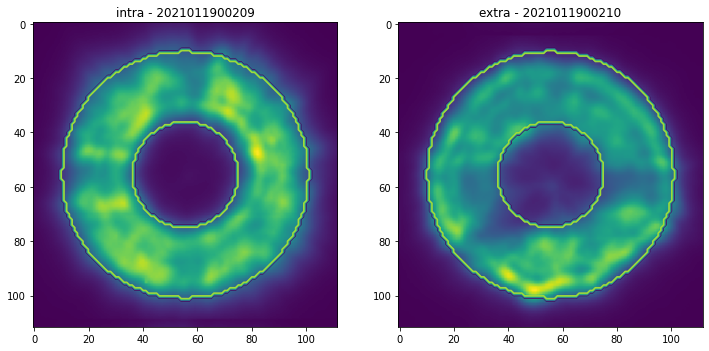

target python read queue is filling: 10 of 100 elements


In [19]:
fig1 = plt.figure(1, figsize=(12,8))
ax11 = fig1.add_subplot(121)
ax11.set_title(f"intra - {cwfs.intra_visit_id}")
ax11.imshow(cwfs.I1[0].image0)
ax11.contour(cwfs.algo.pMask) 
ax12 = fig1.add_subplot(122)
ax12.set_title(f"extra - {cwfs.extra_visit_id}")
ax12.imshow(cwfs.I2[0].image0)
ax12.contour(cwfs.algo.pMask) 

In [20]:
await cwfs.atcs.rem.ataos.cmd_disableCorrection.set_start(atspectrograph=True)

In [21]:
await cwfs.latiss.take_object(20.0, 1, filter='RG610', grating='empty_1')

Generating group_id
OBJECT 0001 - 0001


array([2021011900212])

In [22]:
configuration = yaml.safe_dump({"filter": 'RG610', 
                                "grating": 'empty_1',
                                "exposure_time": 20,
                                "dataPath": '/project/shared/auxTel/rerun/quickLook'})
print(configuration)

dataPath: /project/shared/auxTel/rerun/quickLook
exposure_time: 20
filter: RG610
grating: empty_1



In [23]:
config_data = cwfs.cmd_configure.DataType()
config_data.config = configuration
await cwfs.do_configure(config_data)

Using binning factor of 2


In [25]:
cwfs.intra_visit_id = None
cwfs.extra_visit_id = None
cwfs.short_timeout = 10

In [26]:
await cwfs.run_cwfs()

Intra/Extra images not taken. Running take image sequence.
Moving to intra-focal position
ENGTEST 0001 - 0001
Moving to extra-focal position
Taking extra-focal image
ENGTEST 0001 - 0001
logMessage DDS read queue is filling: 21 of 100 elements
Moving hexapod back to zero offset (in-focus) position
intraImage expId for target: 2021011900213
extraImage expId for target: 2021011900214


Exception ignored in: <function SqlRegistry.__del__ at 0x7f06d23e8e60>
Traceback (most recent call last):
  File "/opt/lsst/software/stack/stack/miniconda3-py37_4.8.2-cb4e2dc/Linux64/daf_persistence/21.0.0-2-ga885a99+4aa8b35973/python/lsst/daf/persistence/registries.py", line 317, in __del__
    self.conn.close()
sqlite3.ProgrammingError: SQLite objects created in a thread can only be used in that same thread. The object was created in thread id 139669368932096 and this is thread id 139670266550016.
Exception ignored in: <function SqlRegistry.__del__ at 0x7f06d23e8e60>
Traceback (most recent call last):
  File "/opt/lsst/software/stack/stack/miniconda3-py37_4.8.2-cb4e2dc/Linux64/daf_persistence/21.0.0-2-ga885a99+4aa8b35973/python/lsst/daf/persistence/registries.py", line 317, in __del__
    self.conn.close()
sqlite3.ProgrammingError: SQLite objects created in a thread can only be used in that same thread. The object was created in thread id 139669368932096 and this is thread id 1396702

Checking for header correction file named LATISS-AT_O_20210119_000213.yaml
AT_O_20210119_000213: Forcing detector serial to ITL-3800C-068
AT_O_20210119_000213: Forcing SHUTTIME header to be None
Checking for header correction file named LATISS-AT_O_20210119_000213.yaml
AT_O_20210119_000213: Forcing detector serial to ITL-3800C-068
AT_O_20210119_000213: Forcing SHUTTIME header to be None
Checking for header correction file named LATISS-AT_O_20210119_000213.yaml
AT_O_20210119_000213: Forcing detector serial to ITL-3800C-068
AT_O_20210119_000213: Forcing SHUTTIME header to be None
Checking for header correction file named LATISS-AT_O_20210119_000213.yaml
AT_O_20210119_000213: Forcing detector serial to ITL-3800C-068
AT_O_20210119_000213: Forcing SHUTTIME header to be None
Checking for header correction file named LATISS-AT_O_20210119_000213.yaml
AT_O_20210119_000213: Forcing detector serial to ITL-3800C-068
AT_O_20210119_000213: Forcing SHUTTIME header to be None
Checking for header corre

{'zerns': [-28.015577784400747, 3.8113006826776856, 122.26606636967927],
 'rot_zerns': array([-28.10703242,  -3.06485563, 122.26606637]),
 'hex_offset': array([-0.1364419 ,  0.01487794, -0.02949709]),
 'tel_offset': array([-8.1865143,  0.8926764,  0.       ])}

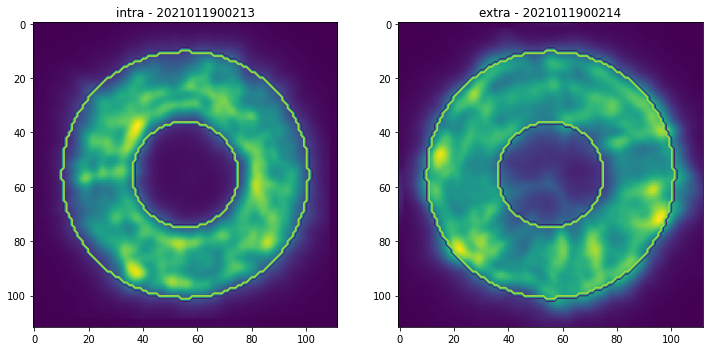

target python read queue is filling: 10 of 100 elements


In [27]:
fig1 = plt.figure(1, figsize=(12,8))
ax11 = fig1.add_subplot(121)
ax11.set_title(f"intra - {cwfs.intra_visit_id}")
ax11.imshow(cwfs.I1[0].image0)
ax11.contour(cwfs.algo.pMask) 
ax12 = fig1.add_subplot(122)
ax12.set_title(f"extra - {cwfs.extra_visit_id}")
ax12.imshow(cwfs.I2[0].image0)
ax12.contour(cwfs.algo.pMask) 

In [29]:
await cwfs.atcs.rem.ataos.cmd_offset.set_start(z=-0.02949709)

In [30]:
cwfs.intra_visit_id = None
cwfs.extra_visit_id = None
cwfs.short_timeout = 10

In [31]:
await cwfs.run_cwfs()

Intra/Extra images not taken. Running take image sequence.
Moving to intra-focal position
ENGTEST 0001 - 0001
Moving to extra-focal position
Taking extra-focal image
ENGTEST 0001 - 0001
Moving hexapod back to zero offset (in-focus) position
intraImage expId for target: 2021011900215
extraImage expId for target: 2021011900216


Exception ignored in: <function SqlRegistry.__del__ at 0x7f06d23e8e60>
Traceback (most recent call last):
  File "/opt/lsst/software/stack/stack/miniconda3-py37_4.8.2-cb4e2dc/Linux64/daf_persistence/21.0.0-2-ga885a99+4aa8b35973/python/lsst/daf/persistence/registries.py", line 317, in __del__
    self.conn.close()
sqlite3.ProgrammingError: SQLite objects created in a thread can only be used in that same thread. The object was created in thread id 139670266550016 and this is thread id 139668938991360.
Exception ignored in: <function SqlRegistry.__del__ at 0x7f06d23e8e60>
Traceback (most recent call last):
  File "/opt/lsst/software/stack/stack/miniconda3-py37_4.8.2-cb4e2dc/Linux64/daf_persistence/21.0.0-2-ga885a99+4aa8b35973/python/lsst/daf/persistence/registries.py", line 317, in __del__
    self.conn.close()
sqlite3.ProgrammingError: SQLite objects created in a thread can only be used in that same thread. The object was created in thread id 139670266550016 and this is thread id 1396689

Checking for header correction file named LATISS-AT_O_20210119_000215.yaml
AT_O_20210119_000215: Forcing detector serial to ITL-3800C-068
AT_O_20210119_000215: Forcing SHUTTIME header to be None
Checking for header correction file named LATISS-AT_O_20210119_000215.yaml
AT_O_20210119_000215: Forcing detector serial to ITL-3800C-068
AT_O_20210119_000215: Forcing SHUTTIME header to be None
Checking for header correction file named LATISS-AT_O_20210119_000215.yaml
AT_O_20210119_000215: Forcing detector serial to ITL-3800C-068
AT_O_20210119_000215: Forcing SHUTTIME header to be None
Checking for header correction file named LATISS-AT_O_20210119_000215.yaml
AT_O_20210119_000215: Forcing detector serial to ITL-3800C-068
AT_O_20210119_000215: Forcing SHUTTIME header to be None
Checking for header correction file named LATISS-AT_O_20210119_000215.yaml
AT_O_20210119_000215: Forcing detector serial to ITL-3800C-068
AT_O_20210119_000215: Forcing SHUTTIME header to be None
Checking for header corre

{'zerns': [-22.78615180609283, -16.16480244465597, -26.874092859572915],
 'rot_zerns': array([-16.8373335 , -22.29380526, -26.87409286]),
 'hex_offset': array([-0.08173463,  0.10822236,  0.00358997]),
 'tel_offset': array([-4.90407772,  6.49334134,  0.        ])}

In [32]:
await cwfs.latiss.take_object(20.0, 1, filter='RG610', grating='empty_1')

Generating group_id
OBJECT 0001 - 0001


array([2021011900217])

In [33]:
test = await cwfs.atcs.rem.ataos.evt_focusOffsetSummary.aget()
print(test)

private_revCode: d8296953, private_sndStamp: 1611120284.8534875, private_rcvStamp: 1611120284.8537295, private_seqNum: 120, private_identity: ATAOS, private_origin: 165593, private_host: 0, total: -0.2180367410182953, userApplied: -0.07403673976659775, filter: -0.01600000075995922, disperser: 0.0, wavelength: 0.0, priority: 0


In [34]:
await cwfs.latiss.setup_atspec(filter='BG40', grating='empty_1')

In [35]:
configuration = yaml.safe_dump({"filter": 'BG40', 
                                "grating": 'empty_1',
                                "exposure_time": 20,
                                "dataPath": '/project/shared/auxTel/rerun/quickLook'})
print(configuration)

dataPath: /project/shared/auxTel/rerun/quickLook
exposure_time: 20
filter: BG40
grating: empty_1



In [37]:
cwfs.set_state(ScriptState.UNCONFIGURED)

In [38]:
config_data = cwfs.cmd_configure.DataType()
config_data.config = configuration
await cwfs.do_configure(config_data)

Using binning factor of 2


In [39]:
cwfs.intra_visit_id = None
cwfs.extra_visit_id = None
cwfs.short_timeout = 10

In [40]:
await cwfs.run_cwfs()

Intra/Extra images not taken. Running take image sequence.
Moving to intra-focal position
ENGTEST 0001 - 0001
Moving to extra-focal position
Taking extra-focal image
ENGTEST 0001 - 0001
Moving hexapod back to zero offset (in-focus) position
intraImage expId for target: 2021011900218
extraImage expId for target: 2021011900219


Exception ignored in: <function SqlRegistry.__del__ at 0x7f06d23e8e60>
Traceback (most recent call last):
  File "/opt/lsst/software/stack/stack/miniconda3-py37_4.8.2-cb4e2dc/Linux64/daf_persistence/21.0.0-2-ga885a99+4aa8b35973/python/lsst/daf/persistence/registries.py", line 317, in __del__
    self.conn.close()
sqlite3.ProgrammingError: SQLite objects created in a thread can only be used in that same thread. The object was created in thread id 139668938991360 and this is thread id 139662068807424.
Exception ignored in: <function SqlRegistry.__del__ at 0x7f06d23e8e60>
Traceback (most recent call last):
  File "/opt/lsst/software/stack/stack/miniconda3-py37_4.8.2-cb4e2dc/Linux64/daf_persistence/21.0.0-2-ga885a99+4aa8b35973/python/lsst/daf/persistence/registries.py", line 317, in __del__
    self.conn.close()
sqlite3.ProgrammingError: SQLite objects created in a thread can only be used in that same thread. The object was created in thread id 139668938991360 and this is thread id 1396620

Checking for header correction file named LATISS-AT_O_20210119_000218.yaml
AT_O_20210119_000218: Forcing detector serial to ITL-3800C-068
AT_O_20210119_000218: Forcing SHUTTIME header to be None
Checking for header correction file named LATISS-AT_O_20210119_000218.yaml
AT_O_20210119_000218: Forcing detector serial to ITL-3800C-068
AT_O_20210119_000218: Forcing SHUTTIME header to be None
Checking for header correction file named LATISS-AT_O_20210119_000218.yaml
AT_O_20210119_000218: Forcing detector serial to ITL-3800C-068
AT_O_20210119_000218: Forcing SHUTTIME header to be None
Checking for header correction file named LATISS-AT_O_20210119_000218.yaml
AT_O_20210119_000218: Forcing detector serial to ITL-3800C-068
AT_O_20210119_000218: Forcing SHUTTIME header to be None
Checking for header correction file named LATISS-AT_O_20210119_000218.yaml
AT_O_20210119_000218: Forcing detector serial to ITL-3800C-068
AT_O_20210119_000218: Forcing SHUTTIME header to be None
Checking for header corre

{'zerns': [-60.113158629330556, 7.129293799480269, 31.331578058832356],
 'rot_zerns': array([-57.07826266, -20.1616121 ,  31.33157806]),
 'hex_offset': array([-0.27707894,  0.0978719 , -0.00999991]),
 'tel_offset': array([-16.6247367,   5.8723142,   0.       ])}

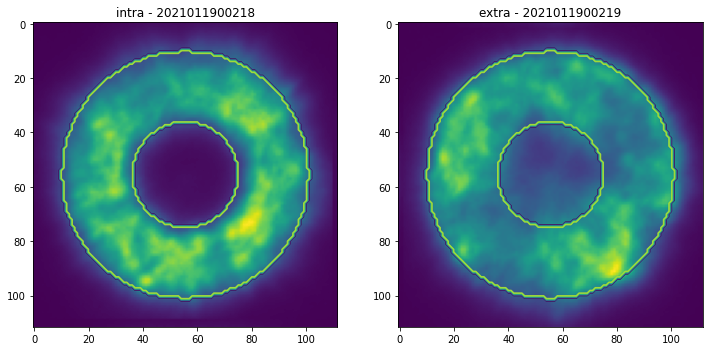

target python read queue is filling: 10 of 100 elements


In [41]:
fig1 = plt.figure(1, figsize=(12,8))
ax11 = fig1.add_subplot(121)
ax11.set_title(f"intra - {cwfs.intra_visit_id}")
ax11.imshow(cwfs.I1[0].image0)
ax11.contour(cwfs.algo.pMask) 
ax12 = fig1.add_subplot(122)
ax12.set_title(f"extra - {cwfs.extra_visit_id}")
ax12.imshow(cwfs.I2[0].image0)
ax12.contour(cwfs.algo.pMask) 

In [42]:
await cwfs.latiss.take_object(20.0, 1, filter='BG40', grating='empty_1')

Generating group_id
OBJECT 0001 - 0001


array([2021011900220])

In [ ]:
# Now running a focus sweep with the grating in place 

In [43]:
await cwfs.latiss.take_object(20.0, 1, filter='empty_1', grating='ronchi90lpmm')

Generating group_id
OBJECT 0001 - 0001


array([2021011900221])

In [44]:
test = await cwfs.atcs.rem.ataos.evt_focusOffsetSummary.aget()
print(test)

private_revCode: d8296953, private_sndStamp: 1611121076.6712413, private_rcvStamp: 1611121076.6715534, private_seqNum: 123, private_identity: ATAOS, private_origin: 165593, private_host: 0, total: -0.3610367476940155, userApplied: -0.07403673976659775, filter: -0.01899999938905239, disperser: 0.0, wavelength: 0.0, priority: 0


In [46]:
import math
#Focus units are given in mm 
focus_center = -0.2155
focus_step = 0.02
n_steps = 9
focus_positions = np.linspace(focus_center - focus_step * math.floor(n_steps / 2), focus_center + focus_step * math.ceil(n_steps / 2 - 1), n_steps)
#focus_positions = [0.05, -0.05, -0.100, -0.150, -0.200, -0.250, -0.300, -0.3, -0.2, -0.2, -0.24, -0.26, -0.28]
print ('focus_positions = ' + str([pos for pos in focus_positions]))

focus_positions = [-0.2955, -0.27549999999999997, -0.2555, -0.2355, -0.2155, -0.1955, -0.1755, -0.1555, -0.1355]


In [47]:
exp_time = 5.0 
filter_str = 'empty_1'
grating_str = 'ronchi90lpmm'

In [48]:
await cwfs.atcs.slew_object('HD61597', rot_type=2)

Starting new HTTP connection (1): simbad.u-strasbg.fr:80
http://simbad.u-strasbg.fr:80 "POST /simbad/sim-script HTTP/1.1" 200 None
Slewing to HD61597: 07 37 32.1273 -51 25 16.920
Setting rotator position with respect to parallactic angle to 0.0 deg.
Parallactic angle: 50.70677134770077 | Sky Angle: 140.70677134770074
Sending command
Stop tracking.
target python read queue is filling: 30 of 100 elements
Unknown tracking state: 9.
Unknown tracking state: 10.
In Position: True.
Scheduling check coroutines
process as completed...
atmcs: <State.ENABLED: 2>
atptg: <State.ENABLED: 2>
ataos: <State.ENABLED: 2>
atpneumatics: <State.ENABLED: 2>
athexapod: <State.ENABLED: 2>
atdome: <State.ENABLED: 2>
atdometrajectory: <State.ENABLED: 2>
[Telescope] delta Alt = -000.073 deg; delta Az = +000.024 deg; delta N1 = -000.000 deg; delta N2 = +074.810 deg [Dome] delta Az = +000.260 deg
ATDome in position.
[Telescope] delta Alt = -000.000 deg; delta Az = +000.000 deg; delta N1 = +000.000 deg; delta N2 = +

In [49]:
await cwfs.latiss.take_object(20.0, 1, filter='empty_1', grating='ronchi90lpmm')

Generating group_id
OBJECT 0001 - 0001


array([2021011900222])

In [50]:
test = await cwfs.atcs.rem.ataos.evt_focusOffsetSummary.aget()
print(test)

private_revCode: d8296953, private_sndStamp: 1611121076.6712413, private_rcvStamp: 1611121076.6715534, private_seqNum: 123, private_identity: ATAOS, private_origin: 165593, private_host: 0, total: -0.3610367476940155, userApplied: -0.07403673976659775, filter: -0.01899999938905239, disperser: 0.0, wavelength: 0.0, priority: 0


In [51]:
#!!!!DO NOT RUN UNLESS YOU HAVE BEEN CLEARED TO CONTROL TELESCOPE!!!!! 
focus_images = [0 for focus_pos in focus_positions]
for i in range(len(focus_positions)): 
    focus_pos = focus_positions[i] 
    print ('Working on focus position ' + str(focus_pos))
    await cwfs.atcs.focus_offset(focus_pos)
    focus_image = await cwfs.latiss.take_engtest(exptime=exp_time, n=1, filter=filter_str, grating=grating_str) 
    print ('Newest image id is = ' + str(focus_image ) )
    focus_images[i] = int(focus_image )
#This resets the focus position after taking this sequence: 
await cwfs.atcs.focus_offset(focus_pos)

Working on focus position -0.2955
Generating group_id
ENGTEST 0001 - 0001
Newest image id is = [2021011900223]
Working on focus position -0.27549999999999997
Generating group_id
ENGTEST 0001 - 0001
Newest image id is = [2021011900224]
Working on focus position -0.2555
Generating group_id
ENGTEST 0001 - 0001
Newest image id is = [2021011900225]
Working on focus position -0.2355
Generating group_id
ENGTEST 0001 - 0001
Newest image id is = [2021011900226]
Working on focus position -0.2155
Generating group_id
ENGTEST 0001 - 0001
Newest image id is = [2021011900227]
Working on focus position -0.1955
Generating group_id
ENGTEST 0001 - 0001
Newest image id is = [2021011900228]
Working on focus position -0.1755
Generating group_id
ENGTEST 0001 - 0001
Newest image id is = [2021011900229]
Working on focus position -0.1555
Generating group_id
ENGTEST 0001 - 0001
Newest image id is = [2021011900230]
Working on focus position -0.1355
Generating group_id
ENGTEST 0001 - 0001
Newest image id is = [202

In [52]:
await cwfs.latiss.take_object(20.0, 1, filter='empty_1', grating='ronchi90lpmm')

Generating group_id
OBJECT 0001 - 0001


array([2021011900232])

logMessage DDS read queue is filling: 13 of 100 elements


In [50]:
test = await cwfs.atcs.rem.ataos.evt_focusOffsetSummary.aget()
print(test)

private_revCode: d8296953, private_sndStamp: 1611121076.6712413, private_rcvStamp: 1611121076.6715534, private_seqNum: 123, private_identity: ATAOS, private_origin: 165593, private_host: 0, total: -0.3610367476940155, userApplied: -0.07403673976659775, filter: -0.01899999938905239, disperser: 0.0, wavelength: 0.0, priority: 0


In [54]:
await cwfs.atcs.focus_offset(0.2955)

In [55]:
await cwfs.atcs.rem.ataos.cmd_resetOffset.set_start(axis='z')

In [56]:
test = await cwfs.atcs.rem.ataos.evt_focusOffsetSummary.aget()
print(test)

private_revCode: d8296953, private_sndStamp: 1611124067.0942698, private_rcvStamp: 1611124067.0946186, private_seqNum: 136, private_identity: ATAOS, private_origin: 165593, private_host: 0, total: -0.026000000536441803, userApplied: 0.0, filter: 0.0, disperser: -0.026000000536441803, wavelength: 0.0, priority: 0


In [57]:
await cwfs.atcs.focus_offset(-0.0740367397665977)

In [58]:
test = await cwfs.atcs.rem.ataos.evt_focusOffsetSummary.aget()
print(test)

private_revCode: d8296953, private_sndStamp: 1611124151.7032244, private_rcvStamp: 1611124151.7036374, private_seqNum: 137, private_identity: ATAOS, private_origin: 165593, private_host: 0, total: -0.10003674030303955, userApplied: -0.07403673976659775, filter: 0.0, disperser: -0.026000000536441803, wavelength: 0.0, priority: 0


In [59]:
await cwfs.latiss.take_object(20.0, 1, filter='empty_1', grating='ronchi90lpmm')

Generating group_id
OBJECT 0001 - 0001


array([2021011900233])

In [60]:
#Focus units are given in mm 
focus_center = 0.0
focus_step = 0.02
n_steps = 9
focus_positions = np.linspace(focus_center - focus_step * math.floor(n_steps / 2), focus_center + focus_step * math.ceil(n_steps / 2 - 1), n_steps)
#focus_positions = [0.05, -0.05, -0.100, -0.150, -0.200, -0.250, -0.300, -0.3, -0.2, -0.2, -0.24, -0.26, -0.28]
print ('focus_positions = ' + str([pos for pos in focus_positions]))

focus_positions = [-0.08, -0.06, -0.04, -0.020000000000000004, 0.0, 0.020000000000000004, 0.039999999999999994, 0.06000000000000001, 0.08]


In [61]:
#!!!!DO NOT RUN UNLESS YOU HAVE BEEN CLEARED TO CONTROL TELESCOPE!!!!! 
focus_images = [0 for focus_pos in focus_positions]
for i in range(len(focus_positions)): 
    focus_pos = focus_positions[i] 
    print ('Working on focus position ' + str(focus_pos))
    await cwfs.atcs.focus_offset(focus_pos)
    focus_image = await cwfs.latiss.take_engtest(exptime=exp_time, n=1, filter=filter_str, grating=grating_str) 
    print ('Newest image id is = ' + str(focus_image ) )
    focus_images[i] = int(focus_image )
#This resets the focus position after taking this sequence: 
await cwfs.atcs.focus_offset(focus_pos)

Working on focus position -0.08
Generating group_id
ENGTEST 0001 - 0001
Newest image id is = [2021011900234]
Working on focus position -0.06
Generating group_id
ENGTEST 0001 - 0001
Newest image id is = [2021011900235]
Working on focus position -0.04
Generating group_id
ENGTEST 0001 - 0001


Exception ignored in: <function SqlRegistry.__del__ at 0x7f06d23e8e60>
Traceback (most recent call last):
  File "/opt/lsst/software/stack/stack/miniconda3-py37_4.8.2-cb4e2dc/Linux64/daf_persistence/21.0.0-2-ga885a99+4aa8b35973/python/lsst/daf/persistence/registries.py", line 317, in __del__
    self.conn.close()
sqlite3.ProgrammingError: SQLite objects created in a thread can only be used in that same thread. The object was created in thread id 139662068807424 and this is thread id 139672455305024.
Exception ignored in: <function SqlRegistry.__del__ at 0x7f06d23e8e60>
Traceback (most recent call last):
  File "/opt/lsst/software/stack/stack/miniconda3-py37_4.8.2-cb4e2dc/Linux64/daf_persistence/21.0.0-2-ga885a99+4aa8b35973/python/lsst/daf/persistence/registries.py", line 317, in __del__
    self.conn.close()
sqlite3.ProgrammingError: SQLite objects created in a thread can only be used in that same thread. The object was created in thread id 139662068807424 and this is thread id 1396724

Newest image id is = [2021011900236]
Working on focus position -0.020000000000000004
Generating group_id
ENGTEST 0001 - 0001
Newest image id is = [2021011900237]
Working on focus position 0.0
Did not received position update from ATHexapod.
Generating group_id
ENGTEST 0001 - 0001
Newest image id is = [2021011900238]
Working on focus position 0.020000000000000004
Generating group_id
ENGTEST 0001 - 0001
Newest image id is = [2021011900239]
Working on focus position 0.039999999999999994
Generating group_id
ENGTEST 0001 - 0001
Newest image id is = [2021011900240]
Working on focus position 0.06000000000000001
Generating group_id
ENGTEST 0001 - 0001
Newest image id is = [2021011900241]
Working on focus position 0.08
Generating group_id
ENGTEST 0001 - 0001
Newest image id is = [2021011900242]


In [62]:
await cwfs.atcs.rem.ataos.cmd_resetOffset.set_start(axis='z')

In [63]:
test = await cwfs.atcs.rem.ataos.evt_focusOffsetSummary.aget()
print(test)

private_revCode: d8296953, private_sndStamp: 1611124709.9989257, private_rcvStamp: 1611124709.9994645, private_seqNum: 148, private_identity: ATAOS, private_origin: 165593, private_host: 0, total: -0.026000000536441803, userApplied: 0.0, filter: 0.0, disperser: -0.026000000536441803, wavelength: 0.0, priority: 0


In [64]:
await cwfs.atcs.focus_offset(-0.0740367397665977)

In [65]:
test = await cwfs.atcs.rem.ataos.evt_focusOffsetSummary.aget()
print(test)

private_revCode: d8296953, private_sndStamp: 1611124718.456421, private_rcvStamp: 1611124718.4569736, private_seqNum: 149, private_identity: ATAOS, private_origin: 165593, private_host: 0, total: -0.10003674030303955, userApplied: -0.07403673976659775, filter: 0.0, disperser: -0.026000000536441803, wavelength: 0.0, priority: 0


In [66]:
focus_window = 0.1
n_step = 9
focus_step = 0.1 / n_step
print(focus_step)

0.011111111111111112


In [67]:
await cwfs.atcs.focus_offset(-focus_window/2.)
for i in range(len(focus_positions)): 
    await cwfs.atcs.focus_offset(focus_step)
    focus_image = await cwfs.latiss.take_engtest(exptime=exp_time, n=1, filter=filter_str, grating=grating_str) 
    print ('Newest image id is = ' + str(focus_image ) )
#     focus_images[i] = int(focus_image )
#This resets the focus position after taking this sequence: 
await cwfs.atcs.focus_offset(-focus_window/2.)

Generating group_id
ENGTEST 0001 - 0001
Newest image id is = [2021011900243]
Generating group_id
ENGTEST 0001 - 0001
Newest image id is = [2021011900244]
Generating group_id
ENGTEST 0001 - 0001
Newest image id is = [2021011900245]
Generating group_id
ENGTEST 0001 - 0001
Newest image id is = [2021011900246]
Generating group_id
ENGTEST 0001 - 0001
Newest image id is = [2021011900247]
Generating group_id
ENGTEST 0001 - 0001
Newest image id is = [2021011900248]
Generating group_id
ENGTEST 0001 - 0001
Newest image id is = [2021011900249]
Generating group_id
ENGTEST 0001 - 0001
Newest image id is = [2021011900250]
Generating group_id
ENGTEST 0001 - 0001
Newest image id is = [2021011900251]


In [70]:
focus_window = 0.13
focus_center = 0.03
n_step = 9
focus_step = 0.13 / n_step
print(focus_step)
exp_time = 30.0

0.014444444444444446


In [71]:
await cwfs.atcs.focus_offset(focus_center)

In [72]:
await cwfs.atcs.focus_offset(-focus_window/2.)
for i in range(n_step): 
    await cwfs.atcs.focus_offset(focus_step)
    focus_image = await cwfs.latiss.take_engtest(exptime=exp_time, n=1, filter=filter_str, grating=grating_str) 
    print ('Newest image id is = ' + str(focus_image ) )
#     focus_images[i] = int(focus_image )
#This resets the focus position after taking this sequence: 
await cwfs.atcs.focus_offset(-focus_window/2.)

Generating group_id
ENGTEST 0001 - 0001
Newest image id is = [2021011900274]
Generating group_id
ENGTEST 0001 - 0001
Newest image id is = [2021011900275]
Generating group_id
ENGTEST 0001 - 0001
Newest image id is = [2021011900276]
Generating group_id
ENGTEST 0001 - 0001
Newest image id is = [2021011900277]
Generating group_id
ENGTEST 0001 - 0001
Newest image id is = [2021011900278]
Generating group_id
ENGTEST 0001 - 0001
Newest image id is = [2021011900279]
Generating group_id
ENGTEST 0001 - 0001
Newest image id is = [2021011900280]
Generating group_id
ENGTEST 0001 - 0001


TimeoutError: 

In [68]:
focus_window = 0.13
n_step = 21
focus_step = focus_window / n_step
print(focus_step)
exp_time = 30.0

0.006190476190476191


In [69]:
await cwfs.atcs.focus_offset(-focus_window/2.)
for i in range(n_step+1): 
    await cwfs.atcs.focus_offset(focus_step)
    focus_image = await cwfs.latiss.take_engtest(exptime=exp_time, n=1, filter=filter_str, grating=grating_str) 
    print ('Newest image id is = ' + str(focus_image ) )
#     focus_images[i] = int(focus_image )
#This resets the focus position after taking this sequence: 
await cwfs.atcs.focus_offset(-focus_window/2.)

Generating group_id
ENGTEST 0001 - 0001
Newest image id is = [2021011900252]
Generating group_id
ENGTEST 0001 - 0001
Newest image id is = [2021011900253]
Generating group_id
ENGTEST 0001 - 0001
Newest image id is = [2021011900254]
Generating group_id
ENGTEST 0001 - 0001
Newest image id is = [2021011900255]
Generating group_id
ENGTEST 0001 - 0001
Newest image id is = [2021011900256]
Generating group_id
ENGTEST 0001 - 0001
Newest image id is = [2021011900257]
Generating group_id
ENGTEST 0001 - 0001
Newest image id is = [2021011900258]
Generating group_id
ENGTEST 0001 - 0001
Newest image id is = [2021011900259]
Generating group_id
ENGTEST 0001 - 0001
Newest image id is = [2021011900260]
Generating group_id
ENGTEST 0001 - 0001
Newest image id is = [2021011900261]
Generating group_id
ENGTEST 0001 - 0001
Newest image id is = [2021011900262]
Generating group_id
ENGTEST 0001 - 0001
Newest image id is = [2021011900263]
Generating group_id
ENGTEST 0001 - 0001
Newest image id is = [2021011900264]

In [73]:
await cwfs.latiss.take_object(30.0, 1, filter='empty_1', grating='ronchi90lpmm')

Generating group_id
OBJECT 0001 - 0001


array([2021011900282])

In [74]:
await cwfs.latiss.take_object(10.0, 1, filter='empty_1', grating='ronchi90lpmm')

Generating group_id
OBJECT 0001 - 0001


array([2021011900283])

In [75]:
await cwfs.latiss.take_object(10.0, 1, filter='empty_1', grating='ronchi90lpmm')

Generating group_id
OBJECT 0001 - 0001


array([2021011900284])

In [76]:
await cwfs.latiss.take_object(10.0, 1, filter='empty_1', grating='ronchi90lpmm')

Generating group_id
OBJECT 0001 - 0001


array([2021011900285])

In [77]:
focus_window = 0.13
n_step = 21
focus_step = focus_window / n_step
print(focus_step)
exp_time = 30.0

0.006190476190476191


In [78]:
await cwfs.atcs.focus_offset(-focus_window/2.)
for i in range(n_step+1): 
    await cwfs.atcs.focus_offset(focus_step)
    focus_image = await cwfs.latiss.take_engtest(exptime=exp_time, n=1, filter=filter_str, grating=grating_str) 
    print ('Newest image id is = ' + str(focus_image ) )
#     focus_images[i] = int(focus_image )
#This resets the focus position after taking this sequence: 
await cwfs.atcs.focus_offset(-focus_window/2.)

Generating group_id
ENGTEST 0001 - 0001
logMessage DDS read queue is filling: 11 of 100 elements
Newest image id is = [2021011900286]
Generating group_id
ENGTEST 0001 - 0001
Newest image id is = [2021011900287]
Generating group_id
ENGTEST 0001 - 0001
Newest image id is = [2021011900288]
Generating group_id
ENGTEST 0001 - 0001
Newest image id is = [2021011900289]
Generating group_id
ENGTEST 0001 - 0001
Newest image id is = [2021011900290]
Generating group_id
ENGTEST 0001 - 0001
Newest image id is = [2021011900291]
Generating group_id
ENGTEST 0001 - 0001
Newest image id is = [2021011900292]
Generating group_id
ENGTEST 0001 - 0001
Newest image id is = [2021011900293]
Generating group_id
ENGTEST 0001 - 0001
Newest image id is = [2021011900294]
Generating group_id
ENGTEST 0001 - 0001
Newest image id is = [2021011900295]
Generating group_id
ENGTEST 0001 - 0001
Newest image id is = [2021011900296]
Generating group_id
ENGTEST 0001 - 0001
Newest image id is = [2021011900297]
Generating group_id

In [79]:
await cwfs.atcs.slew_object('HIP72704', rot_type=2)

Resetting dropped connection: simbad.u-strasbg.fr
http://simbad.u-strasbg.fr:80 "POST /simbad/sim-script HTTP/1.1" 200 None
Slewing to HIP72704: 14 51 53.8728 -27 35 43.409
Setting rotator position with respect to parallactic angle to 0.0 deg.
Parallactic angle: -106.4926188067748 | Sky Angle: -16.4926188067748
Sending command
Stop tracking.
target python read queue is filling: 35 of 100 elements
Unknown tracking state: 9.
Unknown tracking state: 10.
In Position: True.
Scheduling check coroutines
process as completed...
atmcs: <State.ENABLED: 2>
atptg: <State.ENABLED: 2>
ataos: <State.ENABLED: 2>
atpneumatics: <State.ENABLED: 2>
athexapod: <State.ENABLED: 2>
atdome: <State.ENABLED: 2>
atdometrajectory: <State.ENABLED: 2>
[Telescope] delta Alt = +000.009 deg; delta Az = -125.284 deg; delta N1 = +000.000 deg; delta N2 = +033.485 deg [Dome] delta Az = -122.228 deg
[Telescope] delta Alt = +000.001 deg; delta Az = -123.079 deg; delta N1 = -000.000 deg; delta N2 = +028.176 deg [Dome] delta A

In [80]:
await cwfs.latiss.take_object(10.0, 1, filter='empty_1', grating='empty_1')

Generating group_id
OBJECT 0001 - 0001


array([2021011900308])

In [84]:
await cwfs.atcs.shutdown()

Disabling ATAOS corrections
Cover state <MirrorCoverState.CLOSED: 6>
M1 cover already closed.
M1 vent state <VentsPosition.CLOSED: 1>
M1 vents already closed.
Close dome.
ATDome Shutter Door is already closed. Ignoring.
Slew dome to Park position.
Sending ATDomeTrajectory to DISABED state. Component will be left in DISABLEDstate or else it may send the ATDome back to alignment with the telescope.
process as completed...
atdometrajectory: <State.DISABLED: 1>
[Dome] delta Az = -172.490 deg
[Dome] delta Az = -172.390 deg
[Dome] delta Az = -172.030 deg
[Dome] delta Az = -171.450 deg
[Dome] delta Az = -170.630 deg
[Dome] delta Az = -169.590 deg
[Dome] delta Az = -168.300 deg
[Dome] delta Az = -166.790 deg
[Dome] delta Az = -165.040 deg
[Dome] delta Az = -163.050 deg
[Dome] delta Az = -160.830 deg
[Dome] delta Az = -158.380 deg
[Dome] delta Az = -155.700 deg
[Dome] delta Az = -152.780 deg
[Dome] delta Az = -149.660 deg
[Dome] delta Az = -146.290 deg
[Dome] delta Az = -142.850 deg
[Dome] delt

In [83]:
cwfs.atcs.check.atdome=True

In [85]:
await cwfs.latiss.standby()

[atcamera]::[<State.ENABLED: 2>, <State.DISABLED: 1>, <State.STANDBY: 5>]
[atspectrograph]::[<State.ENABLED: 2>, <State.DISABLED: 1>, <State.STANDBY: 5>]
[atheaderservice]::[<State.ENABLED: 2>, <State.DISABLED: 1>, <State.STANDBY: 5>]
[atarchiver]::[<State.ENABLED: 2>, <State.DISABLED: 1>, <State.STANDBY: 5>]
All components in <State.STANDBY: 5>.
